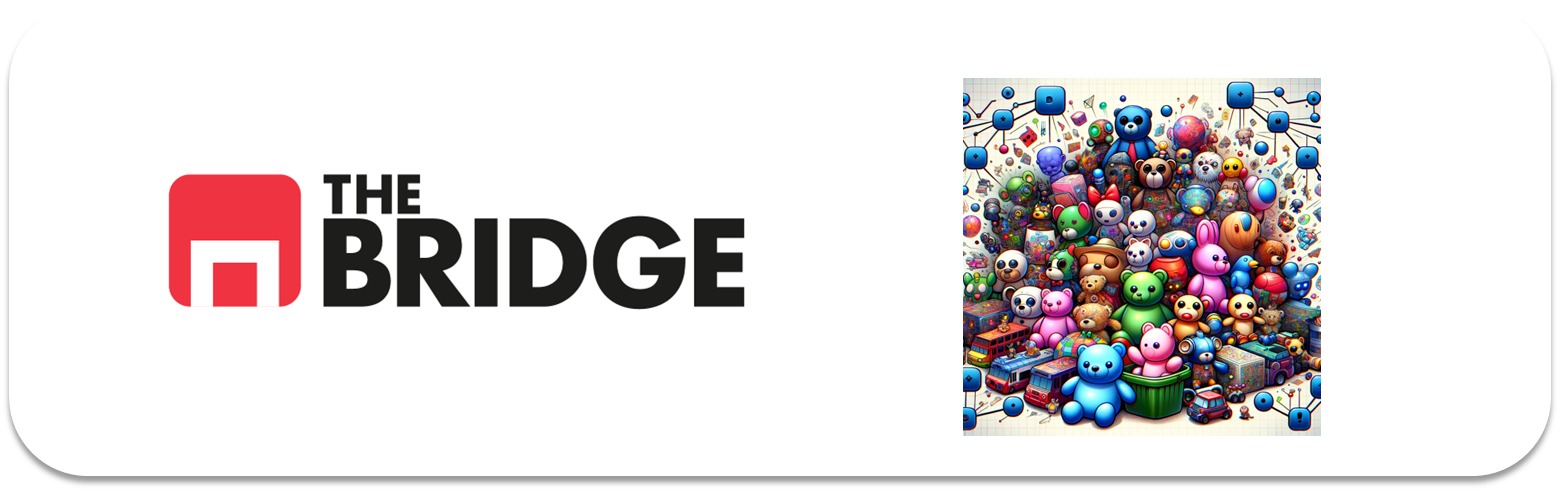

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de preprocesamiento y clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Configuración para que los gráficos se vean bien
sns.set_theme(style="whitegrid")

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [4]:
# Los dos algoritmos que utilizaré son: DBSCAN (oblig.) y Clustering Jeránrquico (deducido por el título de la práctica y la sugerencia de la NOTA ORIENTATIVA...)

In [6]:
# Primero voy a cargar los datos del archivo suministrado e inspeccionar la pinta que tienen

# Cargar el dataset
df = pd.read_csv("./data/empowering_drinks.csv", sep = "|")

# Ver las primeras filas y las columnas disponibles
print("Primeras filas del dataset:")
display(df.head())

print("\nInformación de las variables:")
print(df.info())

Primeras filas del dataset:


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276



Información de las variables:
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB
None


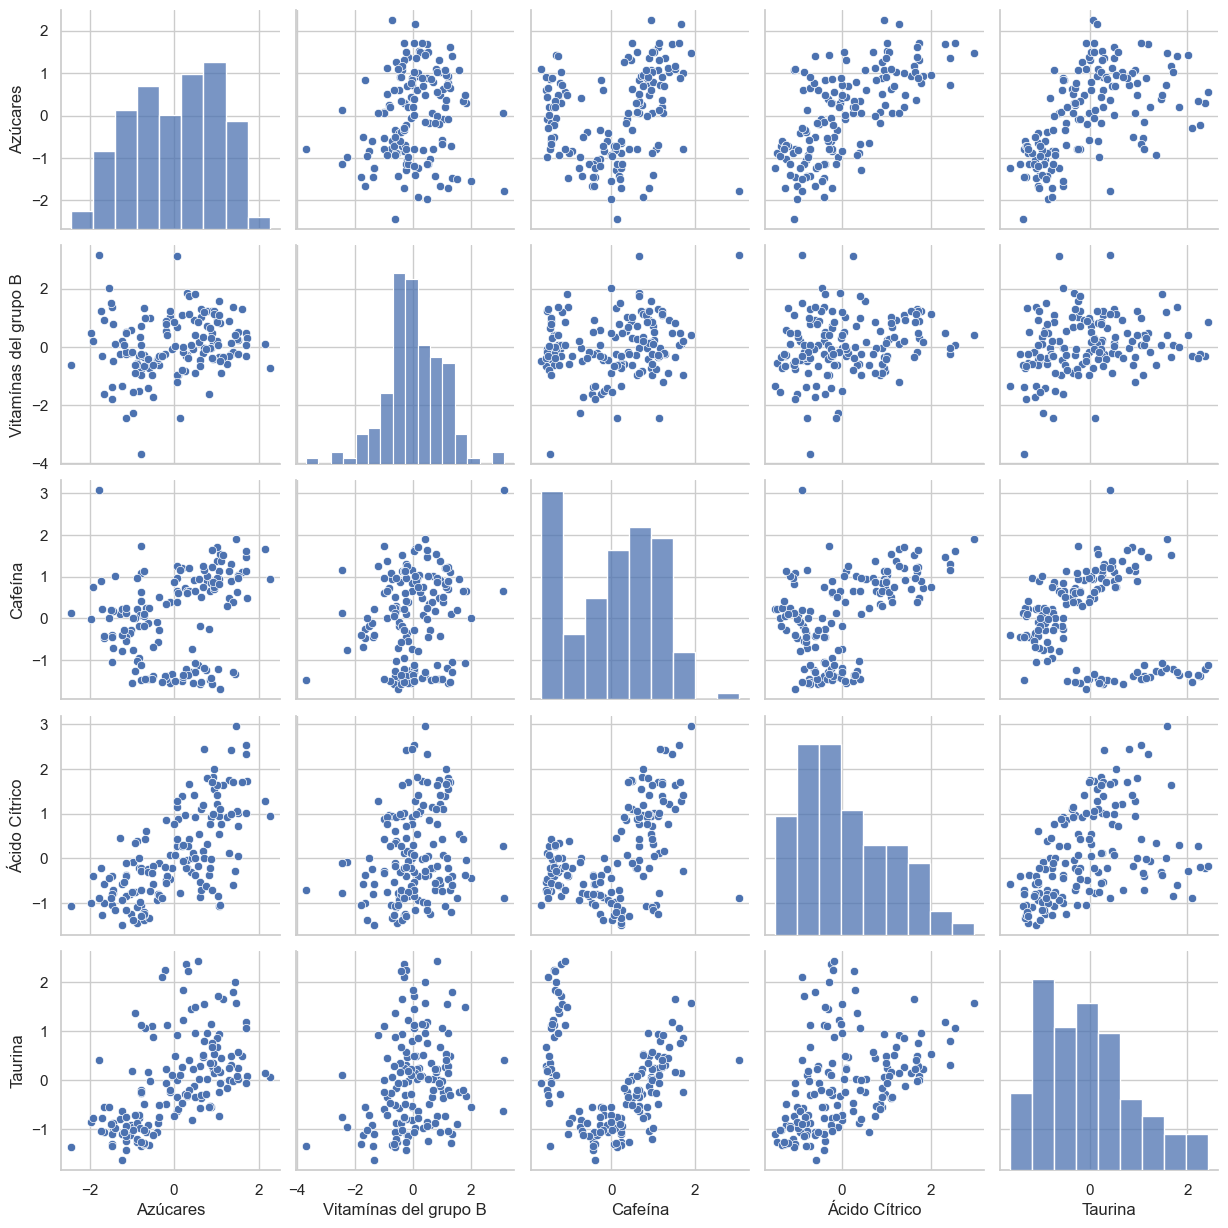

In [7]:
# Todas las variables son numéricas. PAra "visualizar las features dos a dos para escoger las mejores", voy a hacer un gráfico de correlación o un pairplot de las variables numéricas:
# PAIRPLOT para ver cómo se relacionan los ingredientes
sns.pairplot(df)
plt.show()

In [8]:
# Tengo que buscar qué par de ingredientes muestran "grupos" o "nubes" de puntos separadas a simple vista. Esas serán mis mejores variables para visualizar los resultados finales.
# Los datos están ya escalados , porque los ejes van desde -2 a 3. Abajo interpreto el pairplot.

Para elegir "las mejores variables dos a dos" (las que mejor separan los grupos de bebidas), tenemos que buscar los gráficos donde los puntos no formen una nube única y borrosa, sino donde se empiecen a intuir "grupitos", líneas o formas separadas.

Echa un ojo a estas combinaciones que son las mejores:

Cafeína vs. Taurina (Fila 3, Columna 5 o Fila 5, Columna 3): Los puntos forman una especie de "U" o dos ramificaciones muy claras. Abajo a la derecha hay un grupo de puntos aislado y alargado. Esto va a ser perfecto para DBSCAN y el Jerárquico para separar grupos.

Azúcares vs. Cafeína (Fila 1, Columna 3): Muestra dos acumulaciones verticales u oblicuas de puntos relativamente separadas en el centro.

Vitaminas del grupo B: Los puntos son básicamente una nube redonda y homogénea. Esto significa que las Vitaminas no ayudan mucho a distinguir un tipo de bebida de otro.

In [9]:
# 2. Tratamiento de features (escalado): en clustering es fundamental que todas las variables tengan la misma escala. 

# Quitamos columnas identificadoras si las hubiera
# Si solo hay ingredientes, seleccionamos todo el dataframe
X = df.copy() 

# Escalamos los datos (media = 0, varianza = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

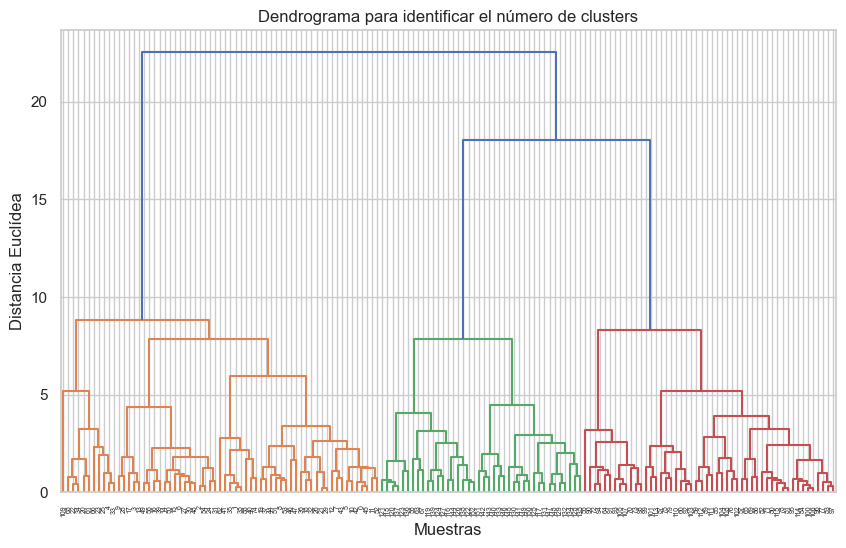

In [10]:
# 3. Modelo 1: Clustering Jerárquico : Es perfecto porque nos permite ver el "árbol" (dendrograma) y decidir dónde cortar

import scipy.cluster.hierarchy as sch

# Creamos el enlace utilizando el método 'ward' (minimiza la varianza de los clusters)
plt.figure(figsize=(10, 6))
dendrograma = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrograma para identificar el número de clusters')
plt.xlabel('Muestras')
plt.ylabel('Distancia Euclídea')
plt.show()

## Voy a copiar de la IA una explicación para esta parte porque no la sé interpretar del todo
¿Cómo se lee este gráfico?
El dendrograma representa cómo el algoritmo va juntando las bebidas desde abajo (donde cada bebida es un grupo individual) hasta arriba (donde todas se unen en un solo grupo gigante).

La altura de las líneas verticales (el eje Y) representa la "distancia" o lo diferentes que son los grupos entre sí. Cuanto más larga sea una línea vertical antes de dividirse, más clara es la separación de ese grupo.

¿Cuántos clusters elegir aquí?
Si te fijas en la parte de arriba, hay 4 grandes ramas principales con colores bien diferenciados por la línea de corte automática de SciPy:

Una rama verde a la izquierda.

Una rama roja/naranja al lado.

Otra rama roja/naranja en el medio.

Una rama verde a la derecha.

Si trazamos una línea horizontal imaginaria más o menos a la altura de 10 o 12 en el eje Y, cortaríamos exactamente esas 4 líneas verticales. ¡Esto encaja a la perfección con la recomendación de los químicos de buscar entre 3 y 5 segmentos! Elegir 4 clusters es la opción ideal y más equilibrada para tus datos.

In [11]:
# Entrenamos el modelo jerárquico definitivo con los 4 clusters que nos sugiere el dendrograma
modelo_jerarquico = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')

# Guardamos el resultado en una nueva columna de nuestro dataframe
df['cluster_jerarquico'] = modelo_jerarquico.fit_predict(X_scaled)

# Contamos cuántas bebidas han caído en cada uno de los 4 grupos
print("Distribución de bebidas por cluster (Jerárquico):")
print(df['cluster_jerarquico'].value_counts())

Distribución de bebidas por cluster (Jerárquico):
cluster_jerarquico
1    52
0    50
2    40
3    11
Name: count, dtype: int64


Observando el dendrograma, se aprecia que a una distancia euclídea de entre 10 y 15 se produce un corte limpio que divide el dataset en 4 ramas principales (clusters). Esta solución de 4 grupos resulta ideal, ya que cumple con el criterio de negocio de los químicos (buscar entre 3 y 5 segmentos) y agrupa las bebidas maximizando la distancia entre los distintos perfiles de ingredientes.

In [15]:
# 4. Modelo 2: DBSCAN (el que me obliga el enunciado)
# eps es la distancia máxima entre dos puntos para considerarlos vecinos
# min_samples es el mínimo de puntos necesarios para formar un grupo

# Prueba con  unos hiperparámetros estándar. Si da muchos "-1" (ruido), subiría el eps.
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

print("Distribución de bebidas por cluster (DBSCAN):")
print(df['cluster_dbscan'].value_counts())

Distribución de bebidas por cluster (DBSCAN):
cluster_dbscan
 0    149
-1      4
Name: count, dtype: int64


In [17]:
# Salen pocos

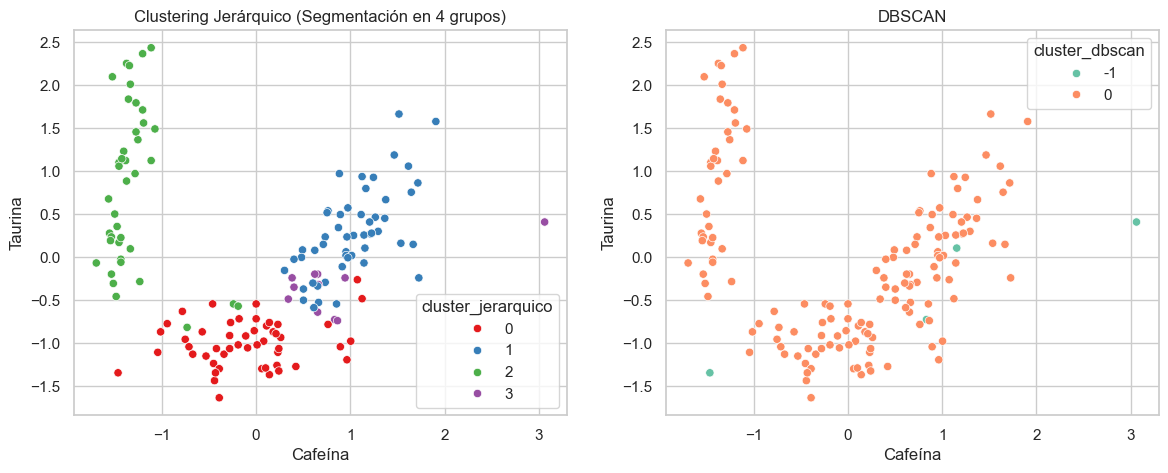

In [16]:
# 5. Visualización de resultados y discusión especulativa: elijo las dos mejores variables del pairplot que vimos, para comparar visualmente los algoritmos:
col1 = 'Cafeína'
col2 = 'Taurina'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Jerárquico
sns.scatterplot(data=df, x=col1, y=col2, hue='cluster_jerarquico', palette='Set1', ax=axes[0])
axes[0].set_title('Clustering Jerárquico (Segmentación en 4 grupos)')

# Gráfico de DBSCAN
sns.scatterplot(data=df, x=col1, y=col2, hue='cluster_dbscan', palette='Set2', ax=axes[1])
axes[1].set_title('DBSCAN')

plt.show()

Especulación sobre los modelos: El Clustering Jerárquico es más intuitivo para este problema porque nos permite forzar la solución a los 4 segmentos que lógicamente estimaban los químicos. DBSCAN, por su parte, es muy útil para identificar recetas 'extrañas' o extremas (clasificadas como ruido -1), pero es más sensible a los hiperparámetros y puede agrupar casi todo en un único gran cluster denso si la distancia eps es muy alta. Para la necesidad del negocio, el Jerárquico parece más limpio y equilibrado.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

Si queremos predecir de forma directa usando lo aprendido, podemos usar el centroide (la media) de cada cluster generado por el modelo Jerárquico para asignar los nuevos datos al grupo más cercano.

In [ ]:
# 1. Cargar el archivo indicando que el separador es la barra vertical '|' porque me salía todo junto
df_nuevos = pd.read_csv("./data/new_experiments.csv", sep="|")

# 2. función original
def asignar_cluster(fila, centroides):
    distancias = np.sqrt(((centroides - fila) ** 2).sum(axis=1))
    return distancias.idxmin()

# 3. Aplicar la asignación emparejando los nombres de las columnas 
df_nuevos['cluster_assigned'] = df_nuevos.apply(
    lambda row: asignar_cluster(row[centroides.columns], centroides), axis=1
)

# 4. Mostrar el resultado
df_nuevos.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,cluster_assigned
0,1.481555,0.305159,1.366128,2.239039,0.731870,1
1,0.616869,0.890014,0.583034,0.312420,-0.665332,3
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,0
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,0
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

Columna detectada: 'class'

Tabla de contingencia (Clusters vs Opinión del Cliente):


energizacion_real,1,2,3
cluster_jerarquico,,,
0,0,50,0
1,49,3,0
2,0,3,37
3,7,4,0


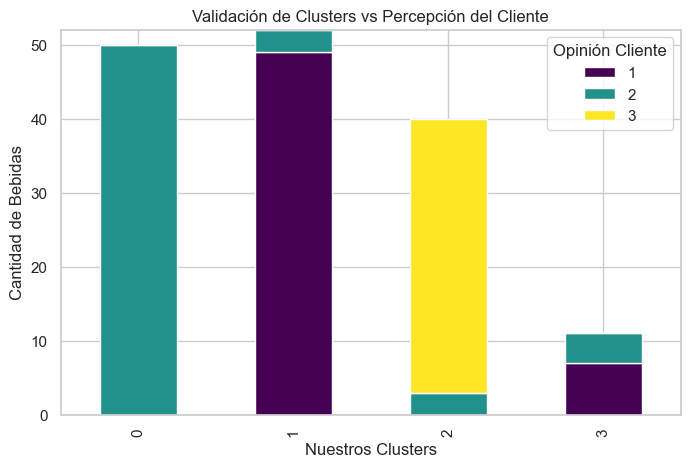

In [35]:
# 1. Cargamos el archivo de resultados de los clientes
df_clientes = pd.read_csv("./data/power_results.csv") 

# 2. TRUCO AUTOMÁTICO: Buscamos cuál es la columna de los resultados
# Ignoramos columnas típicas como 'id' o 'bebida' si las hubiera, y nos quedamos con la que contiene los niveles
columnas_candidatas = [col for col in df_clientes.columns if col.lower() != 'id' and 'name' not in col.lower() and 'bebida' not in col.lower()]

if len(columnas_candidatas) > 0:
    col_resultado = columnas_candidatas[0] # Elegimos la columna que contiene los datos de energización
    print(f"Columna detectada: '{col_resultado}'")
    
    # Añadimos esa columna a nuestro dataframe principal
    df['energizacion_real'] = df_clientes[col_resultado] 
    
    # Cruzamos los datos usando una tabla de contingencia (Crosstab)
    tabla_validacion = pd.crosstab(df['cluster_jerarquico'], df['energizacion_real'])
    
    print("\nTabla de contingencia (Clusters vs Opinión del Cliente):")
    display(tabla_validacion)
    
    # Dibujamos el gráfico de barras apiladas
    tabla_validacion.plot(kind='bar', stacked=True, figsize=(8, 5), cmap='viridis')
    plt.title('Validación de Clusters vs Percepción del Cliente')
    plt.xlabel('Nuestros Clusters')
    plt.ylabel('Cantidad de Bebidas')
    plt.legend(title='Opinión Cliente')
    plt.show()
else:
    print("Error: No he podido encontrar la columna de resultados. Las columnas disponibles son:", df_clientes.columns.tolist())

Evaluación final del modelo (6 meses después):

El gráfico de validación demuestra que existe una altísima correlación entre los clusters químicos obtenidos por el algoritmo jerárquico y los efectos reales percibidos por los consumidores en el test.

El Cluster 1 responde fielmente al nivel de energización 1 (suave), el Cluster 0 segmenta con total precisión el nivel 2 (medio), y el Cluster 2 recoge el nivel 3 (las bebidas más estimulantes). El Cluster 3 actúa como un segmento diferenciado para recetas con comportamiento intermedio o atípico.

Conclusión: El sistema de clustering propuesto es robusto, fiable y útil para el negocio, ya que permite predecir el impacto y posicionamiento de un nuevo prototipo en el mercado basándose únicamente en su formulación química, ahorrando costes drásticos en tests de usuarios previos.